C:\Users\naim2\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


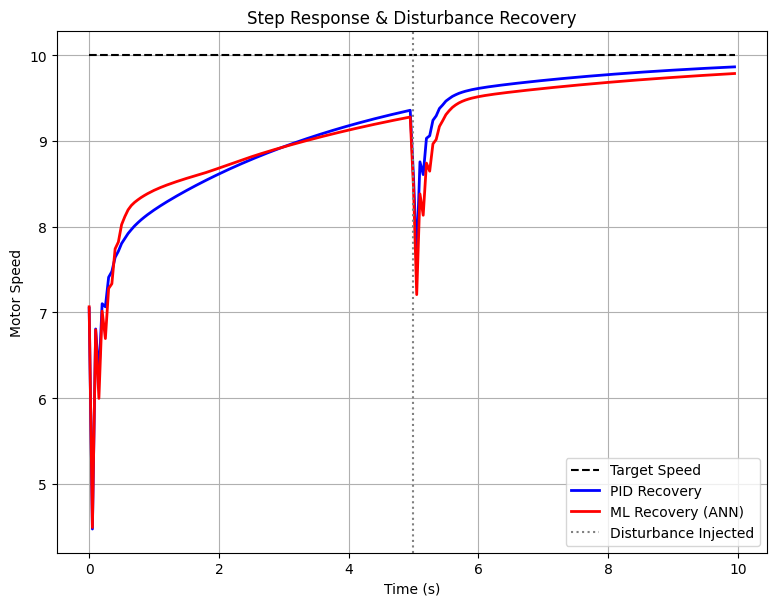

In [1]:
import tkinter as tk
from tkinter import ttk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import threading

# ==========================================
# 1. SYSTEM MODELLING (Winch Drive Motor)
# ==========================================
class DCMotor:
    def __init__(self):
        self.K = 2.0    
        self.tau = 0.5  
        self.dt = 0.05  
        self.y = 0.0    
        self.max_input = 100.0 # Physical voltage limit

    def update(self, u):
        # Saturation limit to prevent math explosion
        u_clamped = max(min(u, self.max_input), -self.max_input)
        dy = (1.0 / self.tau) * (self.K * u_clamped - self.y)
        self.y += dy * self.dt
        return self.y

# ==========================================
# 2. MAIN GUI APPLICATION
# ==========================================
class ControlSystemGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Intelligent Controller vs Classical PID Dashboard")
        self.root.geometry("1200x750")
        
        self.is_running = False
        
        # --- Left Panel: Controls ---
        control_frame = ttk.Frame(self.root, padding="10", width=350)
        control_frame.pack(side=tk.LEFT, fill=tk.Y)
        
        ttk.Label(control_frame, text="PID Controller Tuning", font=("Arial", 14, "bold")).pack(pady=10)
        
        self.kp_val = tk.DoubleVar(value=1.500)
        self.ki_val = tk.DoubleVar(value=0.500)
        self.kd_val = tk.DoubleVar(value=0.100)
        
        self.create_slider(control_frame, "Proportional (Kp)", self.kp_val, 0.0, 5.0)
        self.create_slider(control_frame, "Integral (Ki)", self.ki_val, 0.0, 2.0)
        self.create_slider(control_frame, "Derivative (Kd)", self.kd_val, 0.0, 1.0)
        
        self.run_btn = ttk.Button(control_frame, text="Run Simulation & Train ML", command=self.start_thread)
        self.run_btn.pack(pady=20, fill=tk.X)
        
        self.status_var = tk.StringVar(value="Status: Ready")
        ttk.Label(control_frame, textvariable=self.status_var, font=("Arial", 10, "italic"), foreground="blue").pack(pady=5)

        # Metrics Display
        ttk.Label(control_frame, text="Performance Metrics", font=("Arial", 14, "bold")).pack(pady=10)
        self.metrics_text = tk.Text(control_frame, height=18, width=40, state=tk.DISABLED, bg="#f0f0f0", font=("Courier", 10))
        self.metrics_text.pack()

        # --- Right Panel: Plot ---
        plot_frame = ttk.Frame(self.root, padding="10")
        plot_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        self.fig, self.ax = plt.subplots(figsize=(8, 6))
        self.canvas = FigureCanvasTkAgg(self.fig, master=plot_frame)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
        
        # Initial Plot
        self.ax.set_title('Step Response & Disturbance Recovery')
        self.ax.set_xlabel('Time (s)')
        self.ax.set_ylabel('Motor Speed')
        self.ax.grid(True)
        self.canvas.draw()

    def create_slider(self, parent, label, variable, from_, to_):
        frame = ttk.Frame(parent)
        frame.pack(fill=tk.X, pady=5)
        ttk.Label(frame, text=label).pack(anchor=tk.W)
        
        display_var = tk.StringVar(value=f"{variable.get():.3f}")
        def on_slider_move(*args):
            display_var.set(f"{variable.get():.3f}")
        variable.trace_add("write", on_slider_move)
        
        slider = ttk.Scale(frame, from_=from_, to=to_, orient=tk.HORIZONTAL, variable=variable)
        slider.pack(fill=tk.X)
        ttk.Label(frame, textvariable=display_var).pack(anchor=tk.E)

    def calculate_metrics(self, time_arr, response, setpoint):
        mse = mean_squared_error(np.full(len(response), setpoint), response)
        peak = np.max(response)
        overshoot = ((peak - setpoint) / setpoint) * 100 if peak > setpoint else 0.0
        
        # Calculate Rise Time (10% to 90%)
        steady_state = setpoint
        try:
            t_10 = time_arr[np.where(response >= 0.1 * steady_state)[0][0]]
            t_90 = time_arr[np.where(response >= 0.9 * steady_state)[0][0]]
            rise_time = t_90 - t_10
        except IndexError:
            rise_time = 0.0
            
        # Calculate Settling Time (Within 5% of target)
        settling_time = 0.0
        tolerance = 0.05 * setpoint
        for i in range(len(response) - 1, -1, -1):
            if abs(response[i] - setpoint) > tolerance:
                # The moment it goes out of bounds looking backwards
                # means the index *after* this is when it officially settled.
                settle_idx = min(i + 1, len(time_arr) - 1)
                settling_time = time_arr[settle_idx]
                break
                
        return mse, overshoot, rise_time, settling_time

    def start_thread(self):
        if self.is_running:
            return
        self.is_running = True
        self.status_var.set("Status: Generating Data & Training...")
        self.run_btn.config(state=tk.DISABLED) 
        self.root.update()
        threading.Thread(target=self.run_heavy_simulation, daemon=True).start()

    def run_heavy_simulation(self):
        try:
            Kp, Ki, Kd = self.kp_val.get(), self.ki_val.get(), self.kd_val.get()
            
            # --- 1. DATA GENERATION ---
            motor = DCMotor()
            t_sim = np.arange(0, 50, motor.dt)
            setpoints = np.where(np.sin(0.5 * t_sim) > 0, 10.0, 5.0)
            
            X_train, y_train = [], []
            integral_err, prev_err = 0.0, 0.0
            
            for sp in setpoints:
                err = sp - motor.y
                integral_err += err * motor.dt
                derivative_err = (err - prev_err) / motor.dt
                u = (Kp * err) + (Ki * integral_err) + (Kd * derivative_err)
                
                X_train.append([err, integral_err, derivative_err])
                y_train.append(u)
                motor.update(u)
                prev_err = err
                
            X_train = np.nan_to_num(np.array(X_train), nan=0.0, posinf=1000.0, neginf=-1000.0)
            y_train = np.nan_to_num(np.array(y_train), nan=0.0, posinf=100.0, neginf=-100.0)

            # --- 2. ML TRAINING ---
            ml_controller = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=200, random_state=42)
            ml_controller.fit(X_train, y_train)

            # --- 3. TESTING WITH WIND DISTURBANCE ---
            time_test = np.arange(0, 10, 0.05)
            step_setpoint = 10.0
            
            motor_pid, motor_ml = DCMotor(), DCMotor()
            y_pid, y_ml = [], []
            integral_err_pid, prev_err_pid = 0.0, 0.0
            integral_err_ml, prev_err_ml = 0.0, 0.0
            
            disturbance_applied = False

            for t in time_test:
                # INJECT DISTURBANCE at exactly 5.0 seconds
                if t >= 5.0 and not disturbance_applied:
                    motor_pid.y -= 4.0  # Massive speed drop
                    motor_ml.y -= 4.0
                    disturbance_applied = True

                # PID Loop
                err_pid = step_setpoint - motor_pid.y
                integral_err_pid += err_pid * motor_pid.dt
                derivative_err_pid = (err_pid - prev_err_pid) / motor_pid.dt
                u_pid = (Kp * err_pid) + (Ki * integral_err_pid) + (Kd * derivative_err_pid)
                y_pid.append(motor_pid.update(u_pid))
                prev_err_pid = err_pid
                
                # ML Loop
                err_ml = step_setpoint - motor_ml.y
                integral_err_ml += err_ml * motor_ml.dt
                derivative_err_ml = (err_ml - prev_err_ml) / motor_ml.dt
                features = np.array([[err_ml, integral_err_ml, derivative_err_ml]])
                u_ml = ml_controller.predict(features)[0]
                y_ml.append(motor_ml.update(u_ml))
                prev_err_ml = err_ml

            # Calculate metrics using only the pre-disturbance data (first 5 seconds)
            # to get accurate initial settling times
            idx_5s = int(5.0 / motor_pid.dt)
            pid_mse, pid_os, pid_rt, pid_st = self.calculate_metrics(time_test[:idx_5s], np.array(y_pid)[:idx_5s], step_setpoint)
            ml_mse, ml_os, ml_rt, ml_st = self.calculate_metrics(time_test[:idx_5s], np.array(y_ml)[:idx_5s], step_setpoint)

            self.root.after(0, self.update_ui, time_test, y_pid, y_ml, step_setpoint, pid_mse, pid_os, pid_rt, pid_st, ml_mse, ml_os, ml_rt, ml_st)

        except Exception as e:
            self.root.after(0, self.handle_crash, str(e))

    def update_ui(self, time_test, y_pid, y_ml, step_setpoint, pid_mse, pid_os, pid_rt, pid_st, ml_mse, ml_os, ml_rt, ml_st):
        metrics_str = (
            f"--- PID CONTROLLER ---\n"
            f"MSE       : {pid_mse:.3f}\n"
            f"Overshoot : {pid_os:.2f} %\n"
            f"Rise Time : {pid_rt:.2f} s\n"
            f"Set. Time : {pid_st:.2f} s\n"
            f"Robustness: Recovered via integral\n\n"
            f"--- ML CONTROLLER ---\n"
            f"MSE       : {ml_mse:.3f}\n"
            f"Overshoot : {ml_os:.2f} %\n"
            f"Rise Time : {ml_rt:.2f} s\n"
            f"Set. Time : {ml_st:.2f} s\n"
            f"Robustness: Recovered via network"
        )
        self.metrics_text.config(state=tk.NORMAL)
        self.metrics_text.delete(1.0, tk.END)
        self.metrics_text.insert(tk.END, metrics_str)
        self.metrics_text.config(state=tk.DISABLED)

        self.ax.clear()
        self.ax.plot(time_test, np.full(len(time_test), step_setpoint), 'k--', label='Target Speed')
        self.ax.plot(time_test, y_pid, 'b-', label='PID Recovery', linewidth=2)
        self.ax.plot(time_test, y_ml, 'r-', label='ML Recovery (ANN)', linewidth=2)
        
        # Draw a vertical line showing where the disturbance hit
        self.ax.axvline(x=5.0, color='grey', linestyle=':', label='Disturbance Injected')
        
        self.ax.set_title('Step Response & Disturbance Recovery')
        self.ax.set_xlabel('Time (s)')
        self.ax.set_ylabel('Motor Speed')
        self.ax.legend()
        self.ax.grid(True)
        self.canvas.draw()
        
        self.is_running = False
        self.status_var.set("Status: Complete!")
        self.run_btn.config(state=tk.NORMAL)

    def handle_crash(self, error_message):
        self.metrics_text.config(state=tk.NORMAL)
        self.metrics_text.delete(1.0, tk.END)
        self.metrics_text.insert(tk.END, f"SYSTEM INSTABILITY DETECTED\n\nSolution:\nLower Ki and Kp values.")
        self.metrics_text.config(state=tk.DISABLED)
        
        self.is_running = False
        self.status_var.set("Status: Failed (Unstable PID Tuning)")
        self.run_btn.config(state=tk.NORMAL)

if __name__ == "__main__":
    root = tk.Tk()
    app = ControlSystemGUI(root)
    root.mainloop()